# Vector Operations
**Summer of Science 2026 — CS03: Artificial Intelligence and Machine Learning**  
**Mohit Khyalia | IIT Bombay**

---

## Project Overview

Vectors, dot product, norms, cosine similarity, and projection using NumPy.

### Main goals:

- Implement vector addition, dot product, and norm from definitions.
- Compute cosine similarity and projection between vectors.
- Compare 1D vs 2D NumPy arrays.
- Time a manual loop against `np.dot()`.

---

## Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})

## Creating Vectors

In [2]:
a = np.array([2, 3])
b = np.array([4, -1])

print('a:', a, ' shape:', a.shape)
print('b:', b, ' shape:', b.shape)

a: [2 3]  shape: (2,)
b: [ 4 -1]  shape: (2,)


## Vector Addition and Scalar Multiplication

In [3]:
print('a + b   =', a + b)
print('a - b   =', a - b)
print('3 * a   =', 3 * a)

a + b   = [6 2]
a - b   = [-2  4]
3 * a   = [6 9]


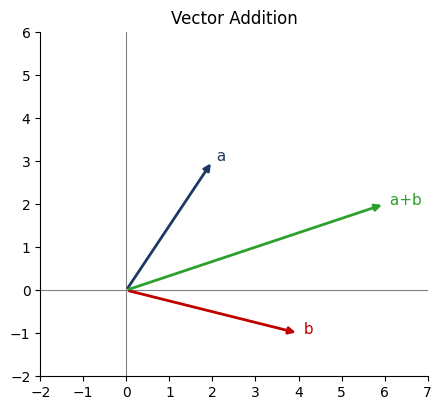

In [4]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.axhline(0, color='gray', lw=0.8)
ax.axvline(0, color='gray', lw=0.8)

ax.annotate('', xy=a, xytext=(0,0), arrowprops=dict(arrowstyle='-|>', color='#1F3864', lw=2))
ax.annotate('', xy=b, xytext=(0,0), arrowprops=dict(arrowstyle='-|>', color='#C00000', lw=2))
ax.annotate('', xy=a+b, xytext=(0,0), arrowprops=dict(arrowstyle='-|>', color='#2CA02C', lw=2))

ax.text(*a, ' a', fontsize=11, color='#1F3864')
ax.text(*b, ' b', fontsize=11, color='#C00000')
ax.text(*(a+b), ' a+b', fontsize=11, color='#2CA02C')

ax.set_xlim(-2, 7)
ax.set_ylim(-2, 6)
ax.set_aspect('equal')
ax.set_title('Vector Addition')
plt.show()

## Dot Product

In [5]:
manual_dot = sum(ai * bi for ai, bi in zip(a, b))
numpy_dot = np.dot(a, b)

print('Manual dot product:', manual_dot)
print('np.dot:', numpy_dot)
print('a @ b:', a @ b)

Manual dot product: 5
np.dot: 5
a @ b: 5


**Observation:**
All three give the same result. `@` is shorthand for `np.dot()` on 1D/2D arrays.

## Norm (Vector Length)

In [6]:
manual_norm = np.sqrt(sum(ai**2 for ai in a))
numpy_norm = np.linalg.norm(a)

print('Manual norm of a:', manual_norm)
print('np.linalg.norm:', numpy_norm)
print('Norm of a == sqrt(a . a):', np.isclose(numpy_norm, np.sqrt(np.dot(a, a))))

Manual norm of a: 3.605551275463989
np.linalg.norm: 3.605551275463989
Norm of a == sqrt(a . a): True


## Cosine Similarity

In [7]:
def cosine_similarity(u, v):
    return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))

print('cos(theta) between a and b:', round(cosine_similarity(a, b), 4))

parallel = np.array([4, 6])
opposite = np.array([-2, -3])
perpendicular = np.array([-3, 2])

print('cos(theta) a vs parallel (2a):     ', round(cosine_similarity(a, parallel), 4))
print('cos(theta) a vs opposite (-a):     ', round(cosine_similarity(a, opposite), 4))
print('cos(theta) a vs perpendicular:     ', round(cosine_similarity(a, perpendicular), 4))

cos(theta) between a and b: 0.3363
cos(theta) a vs parallel (2a):      1.0
cos(theta) a vs opposite (-a):      -1.0
cos(theta) a vs perpendicular:      0.0


**Observation:**
Same direction gives 1, opposite direction gives -1, perpendicular gives 0. Cosine similarity only measures direction, not magnitude — `a` and `2a` give the same score as `a` with itself.

## Projection

In [8]:
def project(u, onto):
    return (np.dot(u, onto) / np.dot(onto, onto)) * onto

proj_b_on_a = project(b, a)
print('Projection of b onto a:', proj_b_on_a)

Projection of b onto a: [0.76923077 1.15384615]


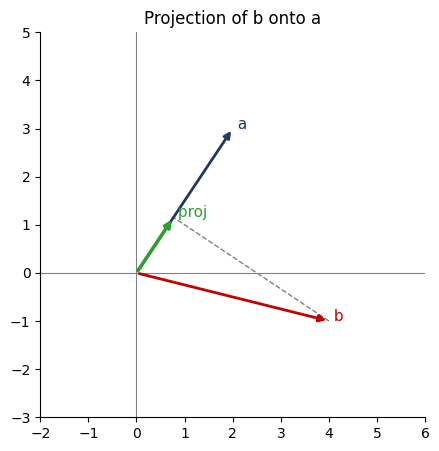

In [9]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.axhline(0, color='gray', lw=0.8)
ax.axvline(0, color='gray', lw=0.8)

ax.annotate('', xy=a, xytext=(0,0), arrowprops=dict(arrowstyle='-|>', color='#1F3864', lw=2))
ax.annotate('', xy=b, xytext=(0,0), arrowprops=dict(arrowstyle='-|>', color='#C00000', lw=2))
ax.annotate('', xy=proj_b_on_a, xytext=(0,0), arrowprops=dict(arrowstyle='-|>', color='#2CA02C', lw=2.5))
ax.plot([b[0], proj_b_on_a[0]], [b[1], proj_b_on_a[1]], '--', color='gray', lw=1)

ax.text(*a, ' a', fontsize=11, color='#1F3864')
ax.text(*b, ' b', fontsize=11, color='#C00000')
ax.text(*proj_b_on_a, ' proj', fontsize=11, color='#2CA02C')

ax.set_xlim(-2, 6)
ax.set_ylim(-3, 5)
ax.set_aspect('equal')
ax.set_title('Projection of b onto a')
plt.show()

## 1D vs 2D Arrays

In [10]:
v1 = np.array([1, 2, 3])
v2 = np.array([[1], [2], [3]])

print('v1 shape:', v1.shape)
print('v2 shape:', v2.shape)
print('v1.reshape(-1,1) shape:', v1.reshape(-1, 1).shape)
print('v2.flatten() shape:', v2.flatten().shape)

v1 shape: (3,)
v2 shape: (3, 1)
v1.reshape(-1,1) shape: (3, 1)
v2.flatten() shape: (3,)


**Observation:**
`(3,)` and `(3,1)` are not the same shape even though they hold the same values — several sklearn functions expect `y` as `(n,)`, not `(n,1)`.

## Timing: Manual Loop vs np.dot()

In [11]:
n = 1_000_000
x = np.random.randn(n)
y = np.random.randn(n)

start = time.time()
manual = sum(xi * yi for xi, yi in zip(x, y))
manual_time = time.time() - start

start = time.time()
vectorized = np.dot(x, y)
vectorized_time = time.time() - start

print(f'Manual loop: {manual_time*1000:.1f} ms')
print(f'np.dot:      {vectorized_time*1000:.2f} ms')
print(f'Speedup:     ~{manual_time/vectorized_time:.0f}x')
print('Results match:', np.isclose(manual, vectorized))

Manual loop: 501.7 ms
np.dot:      3.07 ms
Speedup:     ~164x
Results match: True


**Observation:**
`np.dot()` is orders of magnitude faster on a million-element vector — same operation, but NumPy runs it in compiled C rather than a Python-level loop.